# Dataset

In [1]:
import os
import json

import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch.nn.functional import one_hot
from torch.utils.data import Dataset

class ChromaDataset(Dataset):
    def __init__(self, audio_dir, label_json, sr=16000, num_classes=4, window_size=20, target_bin=25, hop_length=512):
        super().__init__()
        self.sr = sr
        self.target_bin = target_bin
        self.window_frame = window_size*sr//hop_length

        self.num_classes = num_classes
        self.label_map = {"Unknown":0, "우조":1, "계면조":2, "아니리":3, "창조":0, "설렁제":0}

        self.df = self.get_df(label_json)
        self.loaded_audio, self.loaded_label = self.get_audio(audio_dir)
        self.loaded_chroma = self.get_chroma()

    def get_df(self, label_json):
        with open(label_json, "r", encoding="utf-8") as file: label_data = json.load(file)
        df = pd.DataFrame(columns=['filename', 'start', 'end', 'duration', 'label'])

        row = 0
        song_segments = {}
        for song in label_data:
            filename = song['file_upload'][:-3]+'wav'
            if filename not in song_segments: song_segments[filename] = []
            
            for val in song['annotations'][0]["result"]:
                start = val['value']['start']
                end = val['value']['end']
                label = val['value']['labels'][0]
                song_segments[filename].append((start, end, label))

        for filename, segments in song_segments.items():
            prev_end = None
            segments.sort(key=lambda x: x[0])
            for start, end, label in segments:
                if prev_end is not None and int(prev_end) != int(start):
                    gap_start, gap_end = prev_end+1e-6, start-1e-6
                    gap_duration = gap_end - gap_start

                    if gap_duration < 1: continue
                    df.loc[row] = [filename, gap_start, gap_end, gap_duration, "Unknown"]
                    row += 1
                
                duration = end - start
                df.loc[row] = [filename, start, end, duration, label]
                prev_end = end
                row += 1
        return df
    
    def get_audio(self, audio_dir):
        loaded_audio, loaded_label = [], []
        for idx in tqdm(range(len(self.df)), desc='Load Audio'):
            filename, start, duration, label = self.df.iloc[idx]["filename"], self.df.iloc[idx]["start"], self.df.iloc[idx]["duration"], self.df.iloc[idx]["label"]
            try:
                y, _ = librosa.load(path=os.path.join(audio_dir, filename), sr=self.sr, offset=start, duration=duration)
                loaded_audio.append(y)
                loaded_label.append(self.label_map[label])
            except FileNotFoundError as e:
                continue
        print(f"Loaded Audio: {len(loaded_audio)}")
        return loaded_audio, loaded_label
    
    def get_chroma(self):
        chromas = []
        for audio in tqdm(self.loaded_audio, desc="Load Chroma"):
            chroma = librosa.feature.chroma_stft(y=audio, sr=self.sr)
            chroma = np.tile(chroma, (self.target_bin//chroma.shape[0]+1, 1))[:self.target_bin, :]
            chromas.append(chroma)
        return chromas
    
    def __len__(self):
        return len(self.loaded_chroma)

    def __getitem__(self, idx):
        chroma = self.loaded_chroma[idx]
        label = self.loaded_label[idx]

        num_frames = chroma.shape[1]
        
        if num_frames < self.window_frame:
            padding = self.window_frame - num_frames
            chroma_pad = np.zeros((chroma.shape[0], padding))
            chroma = np.concatenate((chroma, chroma_pad), axis=1)
            start_idx = 0
        elif num_frames == self.window_frame:
            start_idx = 0
        else:
            start_idx = np.random.randint(0, num_frames - self.window_frame)
        
        chroma = chroma[:, start_idx:start_idx+self.window_frame]

        time = chroma.shape[1]
        # label = one_hot(torch.tensor(label), self.num_classes).repeat(time, 1).to(dtype=torch.float32)
        label = torch.tensor(label).repeat(time, 1).to(dtype=torch.float32)
        chroma = torch.tensor(chroma, dtype=torch.float32).unsqueeze(0)
        return chroma, label


# audio_dir = "/Users/jcastle/workspace/pansori/Pansori_2025_ISMIR-main/PansoriData/Audio/new"
# label_json = '/Users/jcastle/workspace/pansori/Pansori_2025_ISMIR-main/PansoriData/label.json'
# dset = ChromaDataset(audio_dir=audio_dir, label_json=label_json)

# Model

In [2]:
import torch.nn as nn

class CNNChromagram(nn.Module):
    def __init__(self, target_bin, num_classes):
        super(CNNChromagram, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding = 'same', dilation = (1, 2)) # 1 x T x 12
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding = 'same', dilation  = (1, 2)) # 32 x T x 12
        self.conv3 = nn.Conv2d(64, 128, kernel_size = (3, 3), padding = 'same', dilation = (1, 2)) # 64 x T x 12

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2, 1))

        fc_input_size = 64 * (target_bin // num_classes)

        self.fc1 = nn.Linear(fc_input_size, 64)
        self.fc2 = nn.Linear(64, num_classes)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        batch_size, _, _, time_steps = x.shape

        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch_size, time_steps, -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [4]:
import torch.optim as optim
from sklearn.model_selection import KFold
from tqdm import tqdm

seed = 42

audio_dir = '/Users/jcastle/workspace/pansori/Pansori_2025_ISMIR-main/PansoriData/Audio/new'
label_dir = '/Users/jcastle/workspace/pansori/Pansori_2025_ISMIR-main/PansoriData/label.json'

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
dataset = ChromaDataset(audio_dir, label_dir)

n_splits = 10
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

batch_size = 16
num_epochs = 100
learning_rate = 0.005

results = {'train_loss': [], 'train_accuracy': [],
           'val_loss': [], 'val_accuracy': []}

print('--------------------------------')
for fold, (train_ids, test_ids) in enumerate(kfold.split(dataset)):    
    print(f'FOLD {fold+1}/{n_splits}\n--------------------------------')
    
    model = CNNChromagram(target_bin=25, num_classes=4).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
    test_subsampler = torch.utils.data.SubsetRandomSampler(test_ids)    
    trainloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=train_subsampler)
    testloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=test_subsampler)
    
    best_accuracy = 0.0
    fold_train_loss, fold_train_accuracy = [], []
    fold_val_loss, fold_val_accuracy = [], []
    
    epoch_pbar = tqdm(range(num_epochs), desc=f"Fold {fold+1}/{n_splits}")
    for epoch in epoch_pbar:
        model.train()
        running_loss = 0.0
        correct_train, total_train, batch_count = 0, 0, 0

        for i, data in enumerate(trainloader):
            inputs, targets = data
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs).permute(0, 2, 1)  # batch, num_classes, frame
            
            targets_idx = targets.squeeze(dim=-1).long()
            
            loss = criterion(outputs, targets_idx)
            running_loss += loss.item()
            batch_count += 1

            _, predicted = torch.max(outputs.permute(0, 2, 1), dim=2)  # batch, frame, num_classes -> 예측 클래스
            total_train += targets_idx.numel()
            correct_train += (predicted == targets_idx).sum().item()

            loss.backward()
            optimizer.step()

        avg_train_loss = running_loss / batch_count if batch_count > 0 else 0
        train_accuracy = 100.0 * correct_train / total_train if total_train > 0 else 0
        
        fold_train_loss.append(avg_train_loss)
        fold_train_accuracy.append(train_accuracy)
        
        # Valid
        model.eval()
        val_loss = 0.0
        correct_val, total_val, val_batch_count = 0, 0, 0        
        with torch.no_grad():
            for data in testloader:
                inputs, targets = data
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)  # batch, frame, num_classes
                
                outputs_permuted = outputs.permute(0, 2, 1)  # batch, num_classes, frame (CrossEntropyLoss 형식)
                targets_idx = targets.squeeze(dim=-1).long()  # batch, frame
                
                val_batch_loss = criterion(outputs_permuted, targets_idx)
                val_loss += val_batch_loss.item()
                val_batch_count += 1
                
                _, predicted = torch.max(outputs, dim=2)  # batch, frame
                total_val += targets_idx.numel()
                correct_val += (predicted == targets_idx).sum().item()
        
        avg_val_loss = val_loss / val_batch_count if val_batch_count > 0 else 0
        val_accuracy = 100.0 * correct_val / total_val if total_val > 0 else 0
        
        fold_val_loss.append(avg_val_loss)
        fold_val_accuracy.append(val_accuracy)
        
        epoch_pbar.set_postfix({"train_loss": f"{avg_train_loss:.4f}", "train_acc": f"{train_accuracy:.2f}%",
                                "val_loss": f"{avg_val_loss:.4f}", "val_acc": f"{val_accuracy:.2f}%"})
        
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            save_path = f'./model-fold-{fold+1}-best.pth'
            torch.save(model.state_dict(), save_path)

    results['train_loss'].append(fold_train_loss)
    results['train_accuracy'].append(fold_train_accuracy)
    results['val_loss'].append(fold_val_loss)
    results['val_accuracy'].append(fold_val_accuracy)
    
    print(f'Fold {fold+1} Results:')
    print(f'- Best validation accuracy: {best_accuracy:.2f}%')
    print(f'- Final training accuracy: {train_accuracy:.2f}%')
    print(f'- Final validation accuracy: {val_accuracy:.2f}%')
    print('--------------------------------')

print("\nK-Fold Cross Validation Results:")
print("--------------------------------")
avg_final_train_acc = sum([fold_acc[-1] for fold_acc in results['train_accuracy']]) / n_splits
avg_final_val_acc = sum([fold_acc[-1] for fold_acc in results['val_accuracy']]) / n_splits

print(f"Average final training accuracy: {avg_final_train_acc:.2f}%")
print(f"Average final validation accuracy: {avg_final_val_acc:.2f}%")
print(f"Best fold validation accuracy: {max([max(fold_acc) for fold_acc in results['val_accuracy']]):.2f}%")

Load Audio:  79%|███████▉  | 165/209 [00:03<00:00, 52.50it/s]/var/folders/nl/c_3x6g0n68x745l9b_dd0mmh0000gn/T/ipykernel_29337/1468918811.py:66: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path=os.path.join(audio_dir, filename), sr=self.sr, offset=start, duration=duration)
/Users/jcastle/workspace/pansori/pansori_venv/lib/python3.9/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Load Audio: 100%|██████████| 209/209 [00:03<00:00, 55.78it/s]


Loaded Audio: 168


Load Chroma: 100%|██████████| 168/168 [00:04<00:00, 38.16it/s]


--------------------------------
FOLD 1/10
--------------------------------


Fold 1/10: 100%|██████████| 100/100 [01:18<00:00,  1.28it/s, train_loss=1.1796, train_acc=44.32%, val_loss=1.2405, val_acc=32.17%]


...

Fold 8 Results:
- Best validation accuracy: 56.55%
- Final training accuracy: 45.88%
- Final validation accuracy: 53.20%
--------------------------------
FOLD 9/10
--------------------------------


Fold 9/10: 100%|██████████| 100/100 [01:25<00:00,  1.17it/s, train_loss=1.1356, train_acc=48.31%, val_loss=1.3030, val_acc=31.27%]


Fold 9 Results:
- Best validation accuracy: 42.20%
- Final training accuracy: 48.31%
- Final validation accuracy: 31.27%
--------------------------------
FOLD 10/10
--------------------------------


Fold 10/10: 100%|██████████| 100/100 [01:28<00:00,  1.13it/s, train_loss=1.1820, train_acc=43.09%, val_loss=1.0890, val_acc=54.14%]

Fold 10 Results:
- Best validation accuracy: 55.56%
- Final training accuracy: 43.09%
- Final validation accuracy: 54.14%
--------------------------------

K-Fold Cross Validation Results:
--------------------------------
Average final training accuracy: 45.71%
Average final validation accuracy: 40.68%
Best fold validation accuracy: 57.74%


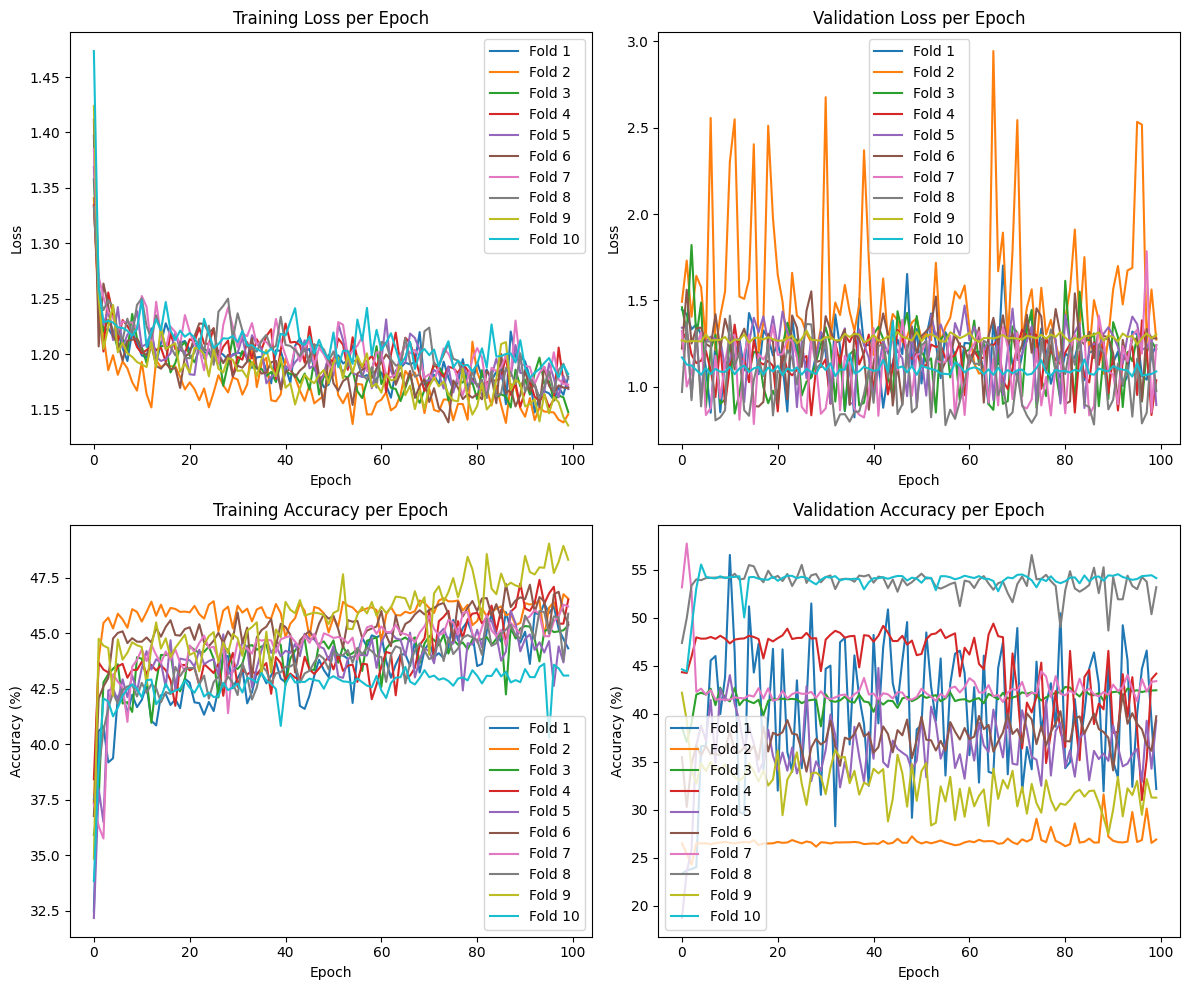

In [5]:
import numpy as np
np.save('kfold_results.npy', results)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
for fold in range(n_splits): plt.plot(results['train_loss'][fold], label=f'Fold {fold+1}')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
for fold in range(n_splits): plt.plot(results['val_loss'][fold], label=f'Fold {fold+1}')
plt.title('Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 3)
for fold in range(n_splits): plt.plot(results['train_accuracy'][fold], label=f'Fold {fold+1}')
plt.title('Training Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.subplot(2, 2, 4)
for fold in range(n_splits): plt.plot(results['val_accuracy'][fold], label=f'Fold {fold+1}')
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('kfold_learning_curves.png')
plt.show()